In [44]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [45]:
model = tf.keras.models.load_model('../../model/clf_model.h5')

In [46]:
def preprocess_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (224, 224))
    img = img / 255.0 
    return img

def predict_image(image_path):
    img = preprocess_image(image_path)
    img = np.expand_dims(img, axis=0)
    prediction = model.predict(img)
    return prediction

1/1 [==============================] - 0s 34ms/step
Predicted class index: 0
Predicted class: Alluvail soil
{This soil is suitable for corps: Rice, SugarCane, Maize,Cotton,Soyabean,Jute}


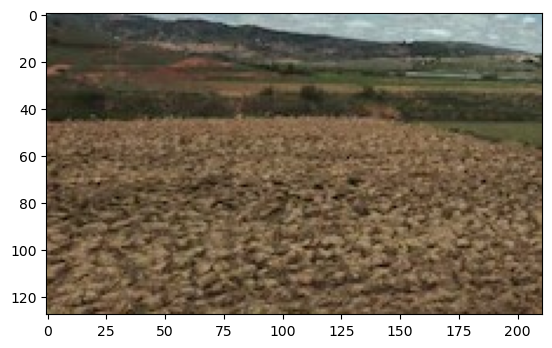

In [50]:
image = '../../dataset/test/Alluvial soil/Alluvial_1.jpg'

prediction = predict_image(image)

predicted_class = np.argmax(prediction, axis=1)[0]
print("Predicted class index:", predicted_class)

indices = prediction.argmax()
soil={"Alluvail soil":"{This soil is suitable for corps: Rice, SugarCane, Maize,Cotton,Soyabean,Jute}",
      "Black Soil":"{This soil is suitable for corps: Wheat, Virginia, Jowar,Millets,Linseed,Castor,Sunflower}",
      "Clay soil":"{This soil is suitable for corps: Rice, Lettuce, Chard,Broccoli,Cabbage,Snap,Beans}",
      "Red soil":"{This soil is suitable for corps: Cotton, Pulses, Millets,OilSeeds,Potatoes}",

}

labels = ['Alluvail soil','Black Soil','Clay soil','Red soil']

print("Predicted class:", labels[predicted_class])
print(soil[labels[predicted_class]])

img = cv2.imread(image)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()